# AnalystLab Africa - Week 3: Machine Learning Fundamentals (Iris Dataset)

## 📖 Concept: Multi-Class Classification & The Golden Rule of Data Splitting

Unlike the Titanic dataset which was **Binary Classification** (0 or 1, Died or Survived), the Iris dataset is a **Multi-Class Classification** problem. We are predicting between three distinct flower species: Setosa, Versicolor, and Virginica.

### The Golden Rule of Machine Learning
**Never touch your test data during preprocessing.** 
If we scale our features or encode our labels using the entire dataset *before* splitting, the mathematical information from the Test Set leaks into the Training Set. The model "cheats" by knowing the average of the test set before the exam even begins. We will strictly split our data **first**, and then fit our scalers and encoders **only** on the training data.

In [1]:
"""
Module: Environment Setup
Purpose: Imports foundational data science libraries and scikit-learn modules for 
         preprocessing, splitting, and multi-class model evaluation.
Time & Space Complexity: O(1) time and space for library loading.
Dependencies: pandas, numpy, matplotlib, seaborn, scikit-learn
"""

# Import the core libraries
import os                                         # For cross-platform file path management
import pandas as pd                               # For data structures and dataframe manipulation
import numpy as np                                # For numerical arrays and mathematical operations
import matplotlib.pyplot as plt                   # For basic plotting and canvas generation
import seaborn as sns                             # For advanced statistical data visualization
from sklearn.model_selection import train_test_split # To divide data into training and testing subsets
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report # For evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder # For feature scaling and target encoding

# Suppress annoying warnings for a cleaner notebook presentation
# This hides deprecation or future warnings from underlying libraries
import warnings
warnings.filterwarnings('ignore')


### Data Loading
We load the raw, untouched `Iris.csv` directly from our data directory to ensure no previous data leakage persists.

In [2]:
"""
Module: Data Ingestion
Purpose: Constructs the correct file path and loads the raw dataset into memory.
Returns: Pandas DataFrame (iris_df)
"""

# Working with the raw csv again due to the data leakage that might have occured 
# as a result of scaling before splitting the data into training and testing data

# Set the directory path to where the dataset are stored
# os.path.join safely creates paths on Windows, Mac, or Linux without slash errors
DATA_DIR = os.path.join('..', 'data', 'raw')

# Load the dataset using pd.read_csv
iris_df = pd.read_csv(os.path.join(DATA_DIR, 'Iris.csv'))


### Initial Data Cleaning (Noise Reduction)
Machine learning models look for patterns. Columns like `Id` are purely administrative (row numbers) and carry zero biological meaning. If left in, a complex model might accidentally "learn" that higher ID numbers correlate with a specific species. 

**Crucially**, we must drop this `Id` column *before* checking for duplicate rows. Because every `Id` is unique (1 to 150), Pandas would otherwise view every row as entirely unique, blinding us to actual duplicate biological measurements.

In [3]:
"""
Module: Baseline Preprocessing
Purpose: Cleans the dataset by dropping the non-predictive 'Id' column first, 
         then removing exact row duplicates based on physical measurements.
Side Effects: Mutates the global `iris_df` DataFrame in place.
Time Complexity: O(N) where N is the number of rows.
"""

# 1. DROP NOISE FIRST
# Drop the 'Id' column if it exists (it's just a row number).
# We must do this BEFORE checking duplicates, otherwise every row looks unique!
iris_df = iris_df.drop(columns=['Id'])
print("Dropped non-predictive 'Id' column.")

# 2. HANDLE DUPLICATES
# Identify and count duplicate rows based on actual biological measurements
duplicates = iris_df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")

# If duplicates exist, drop them. Duplicates can bias the model by artificially 
# inflating the importance of repeated data points.
if duplicates > 0:
    iris_df = iris_df.drop_duplicates()
    print("Duplicates removed.")


Dropped non-predictive 'Id' column.
Total duplicate rows found: 3
Duplicates removed.


### Applying the Golden Rule (Train/Test Split)
Here we physically separate our data *before* performing any mathematical transformations. Notice the use of `stratify=y`. The Iris dataset is perfectly balanced (50 Setosa, 50 Versicolor, 50 Virginica). `stratify` ensures our 80/20 split maintains this exact balance in both the training and testing exams.

In [4]:
"""
Module: Data Splitting
Purpose: Separates independent features (X) from the dependent target (y), then divides 
         them into training and testing sets with stratified class balance.
"""

# THE GOLDEN RULE: Split the data FIRST

# X contains the physical measurements (Sepal/Petal lengths and widths)
X = iris_df.drop('Species', axis=1)

# y contains the answer key (the Species name)
y = iris_df['Species']

# Split the data: 80% for training, 20% for testing.
# stratify=y guarantees equal representation of all 3 species in the test set.
# If we didn't stratify, random chance could put 0 Virginica flowers in our test set!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [5]:
"""
Module: Shape Verification
Purpose: Confirms the row/column dimensions of the split datasets.
"""

# Print the shapes of the resulting matrices to ensure the split was successful
print(f"Iris Training data shape: {X_train.shape}")
print(f"Iris Testing data shape: {X_test.shape}")
print(f"Iris Training Target shape: {y_train.shape}")
print(f"Iris Testing Target shape: {y_test.shape}")


Iris Training data shape: (117, 4)
Iris Testing data shape: (30, 4)
Iris Training Target shape: (117,)
Iris Testing Target shape: (30,)


### Target Encoding (Handling String Labels)
Machine Learning algorithms cannot do math on the string "Iris-setosa". We must convert the target variable into integers. 
* `LabelEncoder` maps unique strings to numbers (e.g., Setosa = 0, Versicolor = 1, Virginica = 2).
* Notice we **fit** the encoder strictly on the training labels.

In [6]:
"""
Module: Target Encoding
Purpose: Converts string class labels into numerical representations.
Data Leakage Prevention: 'fit' is strictly applied to y_train.
"""

# Target Encoding initialization
le = LabelEncoder()

# FIT ONLY ON TRAIN, transform both
# .fit_transform reads the strings in y_train, creates a mapping dictionary, and applies it.
y_train = le.fit_transform(y_train)

# .transform applies the previously learned mapping to the test set.
y_test  = le.transform(y_test) 


### Feature Scaling (Standardization)
Different features are measured on different scales. If Petal Length varies from 1 to 10, but Sepal Width only varies from 0.1 to 0.5, the model will unfairly assume Petal Length is more important just because the numbers are bigger. Scaling normalizes the data to level the playing field.

In [7]:
"""
Module: Feature Normalization
Purpose: Standardizes features by removing the mean and scaling to unit variance.
Data Leakage Prevention: Standard deviation and mean are calculated solely from X_train.
"""

# Feature Scaling initialization
scaler = StandardScaler()

# FIT ONLY ON TRAIN, transform both
# Calculates the mean and standard deviation of X_train, then scales the data.
X_train_scaled = scaler.fit_transform(X_train)

# Scales the test data using the Training set's mathematical rules.
X_test_scaled  = scaler.transform(X_test)

# Rebuild Pandas DataFrames (Scaler outputs raw numpy arrays without column names or indices)
# By passing index=X_train.index, we perfectly preserve the row mappings from our train_test_split
X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Zero Data Leakage.")
print(f"Final Train Shape: {X_train.shape}")


Zero Data Leakage.
Final Train Shape: (117, 4)


In [8]:
"""
Module: Post-Processing Verification
Purpose: Outputs statistical summaries and dataset shapes to ensure scaling 
         was successfully applied (mean ~0, std ~1).
"""

display(X_train.info())
display(X_train.describe()) 
display(X_train.head(10))

print(f"\nIris Training data shape: {X_train.shape}")
print(f"Iris Testing data shape: {X_test.shape}")
print(f"Iris Training Target shape: {y_train.shape}")
print(f"Iris Testing Target shape: {y_test.shape}")


<class 'pandas.DataFrame'>
Index: 117 entries, 67 to 32
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  117 non-null    float64
 1   SepalWidthCm   117 non-null    float64
 2   PetalLengthCm  117 non-null    float64
 3   PetalWidthCm   117 non-null    float64
dtypes: float64(4)
memory usage: 4.6 KB


None

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,1.170000e+02,1.170000e+02,1.170000e+02,1.170000e+02
mean,-6.585425e-16,2.543075e-16,2.846726e-17,1.214603e-16
std,1.004301e+00,1.004301e+00,1.004301e+00,1.004301e+00
min,-1.793942e+00,-2.313067e+00,-1.525869e+00,-1.468511e+00
25%,-8.590144e-01,-5.193382e-01,-1.241682e+00,-1.204383e+00
50%,-1.578189e-01,-7.090595e-02,2.360944e-01,1.162619e-01
75%,6.602425e-01,6.017424e-01,7.476323e-01,7.765841e-01
max,2.413231e+00,3.068120e+00,1.770708e+00,1.701035e+00


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
67,-0.040953,-0.743554,0.179257,-0.279931
90,-0.391551,-0.967770,0.349770,-0.015803
103,0.543377,-0.295122,1.031820,0.776584
52,1.244572,0.153310,0.633957,0.380391
129,1.595170,-0.070906,1.145495,0.512455
109,1.595170,1.274391,1.316008,1.701035
111,0.660242,-0.743554,0.861307,0.908648
41,-1.560210,-1.640419,-1.412194,-1.204383
25,-0.975880,-0.070906,-1.241682,-1.336447
131,2.413231,1.722823,1.486520,1.040713



Iris Training data shape: (117, 4)
Iris Testing data shape: (30, 4)
Iris Training Target shape: (117,)
Iris Testing Target shape: (30,)


## 📖 Concept: Multi-Class Evaluation & The Classification Report

In a multi-class problem, a single "Accuracy" score is highly dangerous. A model might be perfect at identifying Setosa and Versicolor, but completely blind to Virginica. If you only look at overall accuracy, you will deploy a broken model.

To prove this, we intentionally simulate a **Flawed Predictor**. This model is programmed to correctly identify classes 0 and 1, but whenever it sees class 2 (Virginica), it gets confused and guesses 1 (Versicolor).

In [9]:
"""
Module: Flawed Multi-Class Model Simulation
Purpose: Simulates a model that perfectly classifies classes 0 and 1, but utterly fails 
         to detect class 2, proving that global Accuracy hides localized failures.
"""

# MODEL EVALUATION & VISUALIZATION (THE ACCURACY PARADOX) ---
# To demonstrate evaluation metrics before building a real model in Week 4, 
# THE FLAWED MODEL SCENARIO:
# Simulate a model that easily identifies Setosa (0),
# but completely fails and guesses Versicolor (1) whenever it sees a Virginica (2).

# np.where: IF the true label is 2, predict 1. ELSE, predict the true label perfectly.
flawed_iris_preds = np.where(y_test == 2, 1, y_test)

# Accuracy looks decent because it got 2 out of 3 classes right.
acc = accuracy_score(y_test, flawed_iris_preds)

print("--- Flawed Iris Predictor ---")
print(f"Overall Accuracy: {acc:.2f} (Looks like an acceptable baseline)\n")

# THE REVEAL: The classification report breaks down Precision and Recall PER CLASS.
# This exposes that the model has a 0% recall for Virginica, which accuracy completely hid.
print("Detailed Classification Report:")
# target_names=le.classes_ translates the 0,1,2 back into human-readable species names
print(classification_report(y_test, flawed_iris_preds, target_names=le.classes_, zero_division=0))


--- Flawed Iris Predictor ---
Overall Accuracy: 0.67 (Looks like an acceptable baseline)

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.50      1.00      0.67        10
 Iris-virginica       0.00      0.00      0.00        10

       accuracy                           0.67        30
      macro avg       0.50      0.67      0.56        30
   weighted avg       0.50      0.67      0.56        30



### Multi-Class Confusion Matrix
For multi-class data, the Confusion Matrix expands into a grid (e.g., 3x3 for Iris). 
* The **diagonal line** (top-left to bottom-right) represents correct predictions.
* Any numbers outside the diagonal represent specific misclassifications.


Confusion Matrix (3x3):
[[10  0  0]
 [ 0 10  0]
 [ 0 10  0]]


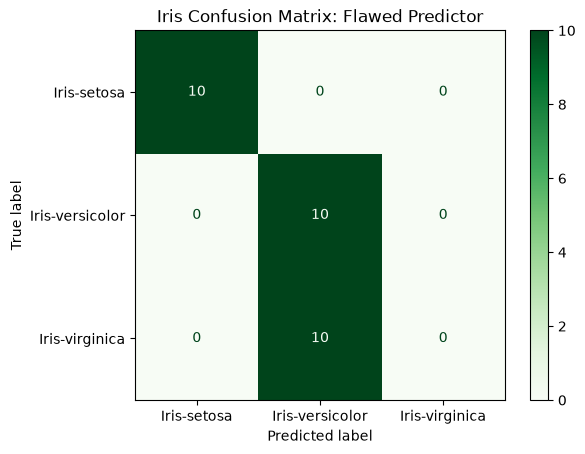

In [10]:
"""
Module: Diagnostic Visualization (Multi-class Confusion Matrix)
Purpose: Plots a 3x3 matrix showing exactly which classes the flawed predictor is confusing.
"""

# The Confusion Matrix visually exposes the exact failure point.
# It generates a 3x3 numpy array mapping True labels to Predicted labels.
cm = confusion_matrix(y_test, flawed_iris_preds)
print("\nConfusion Matrix (3x3):")
print(cm)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# le.classes_ automatically pulls the original string names 
# (e.g., ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot the matrix. 'Greens' colormap is used conceptually for plants/Iris dataset.
disp.plot(cmap='Greens') 
plt.title("Iris Confusion Matrix: Flawed Predictor")
plt.show()
